# Analiza kalibracji fisheye dla 20 sekwencji — training range

Notebook porównuje trzy modele narożników (GRU, LSTM i SSM) oraz klasyczną kalibrację `cv2.fisheye.calibrate()` na zbiorze `data/fisheye_corner_test_seq_training_range`. Każda sekwencja jest oceniana osobno, a końcowe tabele zawierają średnią, odchylenie standardowe, minimum i maksimum dla wszystkich 20 sekwencji.

Dane wejściowe są pobierane bezpośrednio z `data.npz`, z zachowaniem tego samego formatu cech, który jest używany przez modele corner.

In [12]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import pathlib

# Starsze checkpointy zawierają odwołanie do pathlib._local.
sys.modules.setdefault('pathlib._local', pathlib)

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path('/home/dbabiarczyk/studia/semestr10/camera_calibration')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
DATA_DIR = ROOT / 'data/fisheye_corner_test_seq_training_range'
RESULTS_DIR = ROOT / 'outputs/fisheye_corner_test_sequence_training_range_evaluation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINTS = {
    'GRU': ROOT / 'outputs/calibration_net_fisheye/best_model.pth',
    'LSTM': ROOT / 'outputs/calibration_net_fisheye_lstm/best_model.pth',
    'SSM': ROOT / 'outputs/calibration_net_fisheye_ssm/best_model.pth',
}
PARAMETERS = ['fx', 'fy', 'cx', 'cy', 'k1', 'k2', 'k3', 'k4']
IMAGE_SIZE = (1920, 1080)
SEQUENCE_LENGTH = 10
BOARD_SQUARES = (10, 10)
SQUARE_SIZE_MM = 30.0
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
assert DATA_DIR.is_dir(), DATA_DIR
assert all(path.is_file() for path in CHECKPOINTS.values()), 'Brak checkpointu modelu.'
print(f'Device: {DEVICE}')
print(f'Dataset: {DATA_DIR}')

Device: cpu
Dataset: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/fisheye_corner_test_seq_training_range


In [13]:
def load_sequences():
    samples = []
    for sequence_dir in sorted(DATA_DIR.glob('sequence_*')):
        npz_path = sequence_dir / 'data.npz'
        params_path = sequence_dir / 'parameters.json'
        if not npz_path.is_file() or not params_path.is_file():
            raise FileNotFoundError(f'Brak data.npz lub parameters.json w {sequence_dir}')
        data = np.load(npz_path)
        params = json.loads(params_path.read_text(encoding='utf-8'))
        features = np.asarray(data['features'], dtype=np.float32)
        image_points = np.asarray(data['image_points'], dtype=np.float64)
        object_points = np.asarray(data['object_points'], dtype=np.float64)
        target = np.asarray(data['targets'], dtype=np.float64)
        if features.shape != (SEQUENCE_LENGTH, 81, 4):
            raise ValueError(f'{sequence_dir.name}: nieoczekiwany kształt features {features.shape}')
        if image_points.shape != (SEQUENCE_LENGTH, 81, 2):
            raise ValueError(f'{sequence_dir.name}: nieoczekiwany kształt image_points {image_points.shape}')
        samples.append({
            'sequence': sequence_dir.name,
            'features': features,
            'image_points': image_points.reshape(SEQUENCE_LENGTH, 81, 1, 2),
            'object_points': object_points.reshape(81, 1, 3),
            'target': target,
            'parameters': params,
        })
    return samples

samples = load_sequences()
if len(samples) != 20:
    raise ValueError(f'Oczekiwano 20 sekwencji, znaleziono {len(samples)}.')
features = torch.from_numpy(np.stack([sample['features'] for sample in samples]))
ground_truth = np.stack([sample['target'] for sample in samples])
print(f'Wczytano sekwencji: {len(samples)}')
print(f'Wejście sieci: {tuple(features.shape)}')
print(f'Zakres fx w danych GT [px]: {ground_truth[:, 0].min() * IMAGE_SIZE[0]:.2f}–{ground_truth[:, 0].max() * IMAGE_SIZE[0]:.2f}')

Wczytano sekwencji: 20
Wejście sieci: (20, 10, 81, 4)
Zakres fx w danych GT [px]: 961.29–1139.79


In [14]:
from src.networks_tool.models.fisheye_corner_gru_sequence import FisheyeCornerGRUSequenceCalibrationNet
from src.networks_tool.models.fisheye_corner_lstm_sequence import FisheyeCornerLSTMSequenceCalibrationNet
from src.networks_tool.models.fisheye_corner_ssm_sequence import FisheyeCornerSSMSequenceCalibrationNet

MODEL_CLASSES = {
    'GRU': FisheyeCornerGRUSequenceCalibrationNet,
    'LSTM': FisheyeCornerLSTMSequenceCalibrationNet,
    'SSM': FisheyeCornerSSMSequenceCalibrationNet,
}

def load_model(label, checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    model = MODEL_CLASSES[label](num_outputs=8, num_points=81)
    state_dict = checkpoint.get('model_state_dict', checkpoint.get('state_dict', checkpoint))
    model.load_state_dict(state_dict, strict=True)
    model.to(DEVICE).eval()
    return model, checkpoint.get('epoch') if isinstance(checkpoint, dict) else None

models = {}
model_info = []
for label, checkpoint_path in CHECKPOINTS.items():
    model, epoch = load_model(label, checkpoint_path)
    models[label] = model
    model_info.append({'model': label, 'checkpoint': str(checkpoint_path), 'epoch': epoch,
                      'parameters': sum(p.numel() for p in model.parameters())})
display(pd.DataFrame(model_info))

,model,checkpoint,epoch,parameters
0,GRU,/home/dbabiarczyk/studia/semestr10/camera_cali...,28,140648
1,LSTM,/home/dbabiarczyk/studia/semestr10/camera_cali...,53,301672
2,SSM,/home/dbabiarczyk/studia/semestr10/camera_cali...,12,85224


In [21]:
SCALE = np.array([IMAGE_SIZE[0], IMAGE_SIZE[1], IMAGE_SIZE[0], IMAGE_SIZE[1], 1, 1, 1, 1], dtype=np.float64)

def normalized_to_parameters(values):
    return np.asarray(values, dtype=np.float64) * SCALE


def matrices(parameters):
    values = np.asarray(parameters, dtype=np.float64)
    K = np.array([[values[0], 0.0, values[2]], [0.0, values[1], values[3]], [0.0, 0.0, 1.0]])
    return K, values[4:].reshape(4, 1)


def reprojection_error(sample, parameters):
    K, D = matrices(parameters)
    errors = []
    for observed in sample['image_points']:
        try:
            undistorted = cv2.fisheye.undistortPoints(observed, K, D)
            ok, rvec, tvec = cv2.solvePnP(
                sample['object_points'], undistorted, np.eye(3), None,
                flags=cv2.SOLVEPNP_ITERATIVE,
            )
            if not ok:
                continue
            projected, _ = cv2.fisheye.projectPoints(sample['object_points'], rvec, tvec, K, D)
            errors.extend(np.linalg.norm(projected.reshape(-1, 2) - observed.reshape(-1, 2), axis=1))
        except cv2.error:
            continue
    return float(np.mean(errors)) if errors else np.nan


def reprojection_error_with_extrinsics(sample, parameters, rvecs, tvecs, indices=None):
    K, D = matrices(parameters)
    if indices is None:
        indices = range(len(sample['image_points']))
    errors = []
    for local_index, frame_index in enumerate(indices):
        projected, _ = cv2.fisheye.projectPoints(
            sample['object_points'], rvecs[local_index], tvecs[local_index], K, D
        )
        observed = sample['image_points'][frame_index]
        errors.extend(np.linalg.norm(projected.reshape(-1, 2) - observed.reshape(-1, 2), axis=1))
    return float(np.mean(errors)) if errors else np.nan


def classical_calibration(sample):
    K0 = np.array([[IMAGE_SIZE[0], 0, IMAGE_SIZE[0] / 2],
                   [0, IMAGE_SIZE[0], IMAGE_SIZE[1] / 2], [0, 0, 1]], dtype=np.float64)
    D0 = np.zeros((4, 1), dtype=np.float64)
    flags = cv2.fisheye.CALIB_RECOMPUTE_EXTRINSIC | cv2.fisheye.CALIB_FIX_SKEW
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_MAX_ITER, 200, 1e-8)
    candidates = [list(range(SEQUENCE_LENGTH))]
    candidates.extend(
        [index for index in range(SEQUENCE_LENGTH)
         for index in [[frame for frame in range(SEQUENCE_LENGTH) if frame != index]]]
    )
    last_error = None
    for indices in candidates:
        try:
            rms, K, D, rvecs, tvecs = cv2.fisheye.calibrate(
                [sample['object_points'].copy() for _ in indices],
                [sample['image_points'][index] for index in indices],
                IMAGE_SIZE, K0.copy(), D0.copy(), flags=flags, criteria=criteria,
            )
            values = np.array([K[0, 0], K[1, 1], K[0, 2], K[1, 2], *D.ravel()])
            return values, float(rms), len(indices), rvecs, tvecs, indices
        except cv2.error as error:
            last_error = error
    raise last_error


records = []
for sample in samples:
    try:
        start = time.perf_counter()
        prediction, opencv_rms, calibration_frames, rvecs, tvecs, calibration_indices = classical_calibration(sample)
        elapsed = time.perf_counter() - start
        records.append({
            'method': 'OpenCV fisheye', 'sequence': sample['sequence'],
            'prediction': prediction, 'ground_truth': normalized_to_parameters(sample['target']),
            'opencv_rms': opencv_rms,
            'reprojection_px': reprojection_error_with_extrinsics(
                sample, prediction, rvecs, tvecs, calibration_indices
            ),
            'time_s': elapsed, 'success': True, 'calibration_frames': calibration_frames,
        })
    except cv2.error as error:
        print(f"OpenCV nieudane dla {sample['sequence']}: {error}")
        records.append({
            'method': 'OpenCV fisheye', 'sequence': sample['sequence'],
            'prediction': np.full(8, np.nan), 'ground_truth': normalized_to_parameters(sample['target']),
            'opencv_rms': np.nan, 'reprojection_px': np.nan,
            'time_s': np.nan, 'success': False, 'calibration_frames': 0,
        })

for method, model in models.items():
    for sample in samples:
        model_input = sample['features'][None]
        start = time.perf_counter()
        with torch.no_grad():
            output = model(torch.from_numpy(model_input).to(DEVICE)).cpu().numpy()[0]
        elapsed = time.perf_counter() - start
        prediction = normalized_to_parameters(output)
        records.append({
            'method': method, 'sequence': sample['sequence'],
            'prediction': prediction, 'ground_truth': normalized_to_parameters(sample['target']),
            'opencv_rms': np.nan, 'reprojection_px': reprojection_error(sample, prediction),
            'time_s': elapsed, 'success': True, 'calibration_frames': SEQUENCE_LENGTH,
        })

if len(records) != len(samples) * 4:
    raise RuntimeError(f'Oczekiwano {len(samples) * 4} wyników, otrzymano {len(records)}.')
print(f'Liczba wyników: {len(records)} ({len(samples)} sekwencji × 4 metody)')

Liczba wyników: 80 (20 sekwencji × 4 metody)


In [22]:
rows = []
for record in records:
    error = record['prediction'] - record['ground_truth']
    normalized_error = error / SCALE
    row = {
        'metoda': record['method'],
        'sekwencja': record['sequence'],
        'RMSE parametrów norm.': float(np.sqrt(np.mean(normalized_error ** 2))),
        'MAE parametrów norm.': float(np.mean(np.abs(normalized_error))),
        'Błąd reprojekcji [px]': record['reprojection_px'],
        'RMSE OpenCV [px]': record['opencv_rms'],
        'Czas wywołania [s]': record['time_s'],
    }
    for index, name in enumerate(PARAMETERS):
        row[f'{name} błąd bezwzgl.'] = abs(error[index])
        row[f'{name} GT'] = record['ground_truth'][index]
        row[f'{name} pred.'] = record['prediction'][index]
    rows.append(row)

per_sequence_df = pd.DataFrame(rows)
metric_columns = ['RMSE parametrów norm.', 'MAE parametrów norm.', 'Błąd reprojekcji [px]', 'RMSE OpenCV [px]', 'Czas wywołania [s]']
summary_df = per_sequence_df.groupby('metoda')[metric_columns].agg(['mean', 'std', 'min', 'max'])
summary_df.columns = [f'{metric} — {stat}' for metric, stat in summary_df.columns]
summary_df = summary_df.reset_index()

time_summary_df = (
    per_sequence_df.groupby('metoda')['Czas wywołania [s]']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .rename(columns={
        'mean': 'średni czas [s]', 'std': 'odchylenie [s]',
        'min': 'minimum [s]', 'max': 'maksimum [s]', 'count': 'liczba pomiarów',
    })
    .reset_index()
)

parameter_error_rows = []
for method, group in per_sequence_df.groupby('metoda'):
    parameter_error_rows.append({'metoda': method, **{
        name: group[f'{name} błąd bezwzgl.'].mean() for name in PARAMETERS
    }})
parameter_error_df = pd.DataFrame(parameter_error_rows).set_index('metoda')

ranking = (summary_df[['metoda', 'RMSE parametrów norm. — mean', 'MAE parametrów norm. — mean', 'Błąd reprojekcji [px] — mean']]
           .sort_values(['RMSE parametrów norm. — mean', 'Błąd reprojekcji [px] — mean'])
           .reset_index(drop=True))

per_sequence_df.to_csv(RESULTS_DIR / 'wyniki_dla_kazdej_sekwencji.csv', index=False)
summary_df.to_csv(RESULTS_DIR / 'podsumowanie_20_sekwencji.csv', index=False)
time_summary_df.to_csv(RESULTS_DIR / 'czasy_wywolan.csv', index=False)
parameter_error_df.to_csv(RESULTS_DIR / 'sredni_blad_parametrow.csv')

print('Średnie wyniki i rozrzut dla wszystkich 20 sekwencji:')
display(summary_df.round(6))
print('Tabela czasów wywołania metod — jeden pomiar na sekwencję:')
display(time_summary_df.round(6))
print('Średni błąd bezwzględny poszczególnych parametrów:')
display(parameter_error_df.round(4))
print('Ranking: najpierw średni RMSE parametrów, następnie średni błąd reprojekcji (mniej = lepiej):')
display(ranking.round(6))

Średnie wyniki i rozrzut dla wszystkich 20 sekwencji:


,metoda,RMSE parametrów norm. — mean,RMSE parametrów norm. — std,RMSE parametrów norm. — min,RMSE parametrów norm. — max,MAE parametrów norm. — mean,MAE parametrów norm. — std,MAE parametrów norm. — min,MAE parametrów norm. — max,Błąd reprojekcji [px] — mean,...,Błąd reprojekcji [px] — min,Błąd reprojekcji [px] — max,RMSE OpenCV [px] — mean,RMSE OpenCV [px] — std,RMSE OpenCV [px] — min,RMSE OpenCV [px] — max,Czas wywołania [s] — mean,Czas wywołania [s] — std,Czas wywołania [s] — min,Czas wywołania [s] — max
0,GRU,0.051401,0.007586,0.038228,0.065863,0.040161,0.006525,0.029603,0.048816,0.524564,...,0.246805,0.971371,NaN,NaN,NaN,NaN,0.001284,0.002058,0.000692,0.010013
1,LSTM,0.050684,0.007911,0.037243,0.065138,0.039301,0.007206,0.028523,0.050332,0.458812,...,0.181489,0.912150,NaN,NaN,NaN,NaN,0.000970,0.000296,0.000694,0.001785
2,OpenCV fisheye,0.000019,0.000025,0.000000,0.000114,0.000011,0.000014,0.000000,0.000062,0.000026,...,0.000023,0.000030,0.000029,0.000002,0.000026,0.000034,0.030350,0.010211,0.024726,0.063126
3,SSM,0.050837,0.006010,0.036995,0.060693,0.040681,0.005737,0.029798,0.050333,0.498279,...,0.233453,1.144455,NaN,NaN,NaN,NaN,0.001767,0.001350,0.001251,0.007464


Tabela czasów wywołania metod — jeden pomiar na sekwencję:


,metoda,średni czas [s],odchylenie [s],minimum [s],maksimum [s],liczba pomiarów
0,GRU,0.001284,0.002058,0.000692,0.010013,20
1,LSTM,0.000970,0.000296,0.000694,0.001785,20
2,OpenCV fisheye,0.030350,0.010211,0.024726,0.063126,20
3,SSM,0.001767,0.001350,0.001251,0.007464,20


Średni błąd bezwzględny poszczególnych parametrów:


,fx,fy,cx,cy,k1,k2,k3,k4
metoda,,,,,,,,
GRU,43.2291,49.2562,14.9101,12.4026,0.0187,0.0840,0.0545,0.0767
LSTM,40.1789,49.1501,15.2166,11.7131,0.0160,0.0830,0.0561,0.0741
OpenCV fisheye,0.0004,0.0003,0.0002,0.0002,0.0000,0.0000,0.0000,0.0000
SSM,49.0028,48.4001,16.4682,11.4685,0.0195,0.0846,0.0587,0.0732


Ranking: najpierw średni RMSE parametrów, następnie średni błąd reprojekcji (mniej = lepiej):


,metoda,RMSE parametrów norm. — mean,MAE parametrów norm. — mean,Błąd reprojekcji [px] — mean
0,OpenCV fisheye,0.000019,0.000011,0.000026
1,LSTM,0.050684,0.039301,0.458812
2,SSM,0.050837,0.040681,0.498279
3,GRU,0.051401,0.040161,0.524564


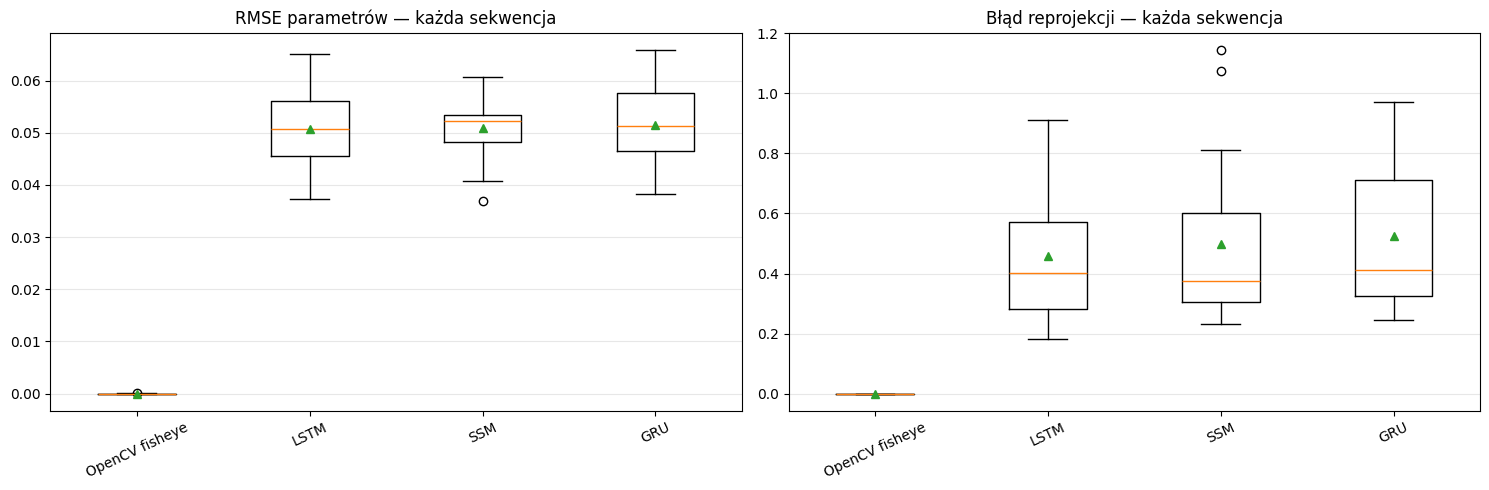

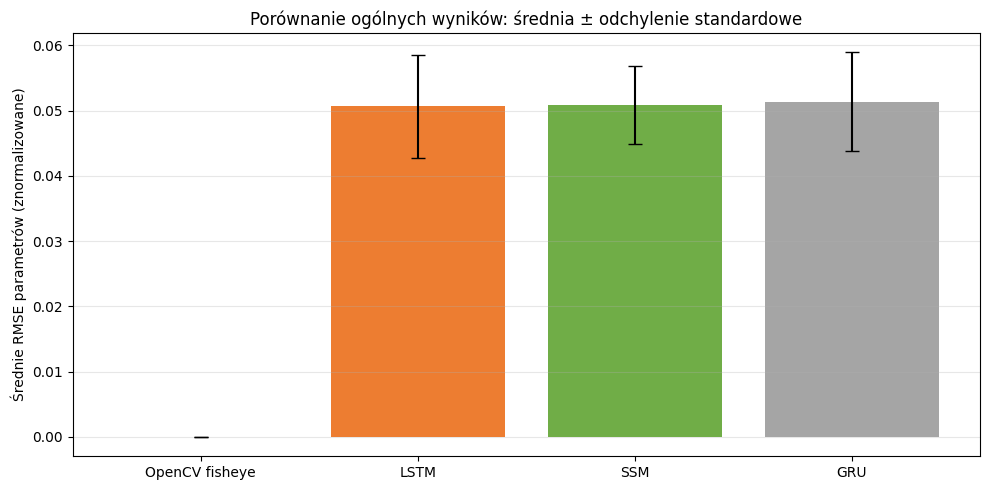

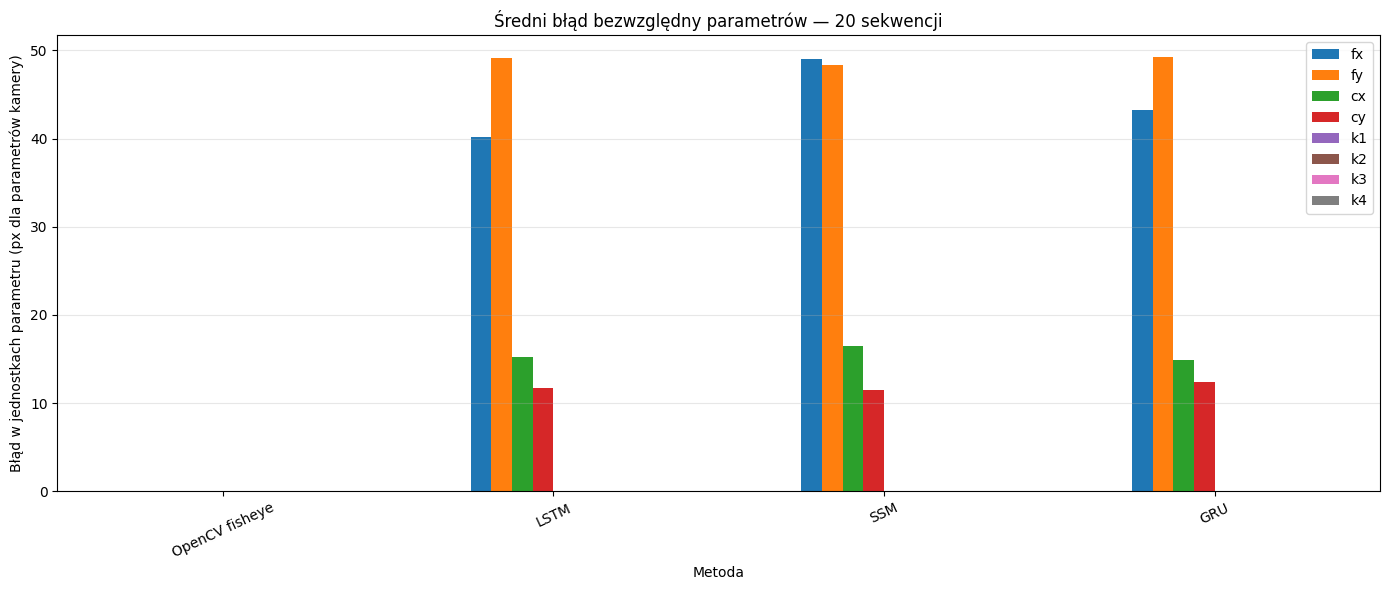

Najlepsza metoda wg średniego RMSE parametrów: OpenCV fisheye (RMSE=0.000019, reprojekcja=0.0000 px).
Pliki wynikowe zapisano w: /home/dbabiarczyk/studia/semestr10/camera_calibration/outputs/fisheye_corner_test_sequence_training_range_evaluation


In [20]:
plot_df = per_sequence_df.rename(columns={
    'metoda': 'Metoda',
    'RMSE parametrów norm.': 'RMSE parametrów',
    'Błąd reprojekcji [px]': 'Reprojekcja [px]',
})
order = ranking['metoda'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, column, title in zip(
    axes,
    ['RMSE parametrów', 'Reprojekcja [px]'],
    ['RMSE parametrów — każda sekwencja', 'Błąd reprojekcji — każda sekwencja'],
):
    data = [plot_df.loc[plot_df['Metoda'] == method, column].dropna().to_numpy() for method in order]
    axis.boxplot(data, tick_labels=order, showmeans=True)
    axis.set_title(title)
    axis.tick_params(axis='x', rotation=25)
    axis.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'rozkład_błędów.png', dpi=180, bbox_inches='tight')
plt.show()

fig, axis = plt.subplots(figsize=(10, 5))
means = [summary_df.loc[summary_df['metoda'] == method, 'RMSE parametrów norm. — mean'].iloc[0] for method in order]
stds = [summary_df.loc[summary_df['metoda'] == method, 'RMSE parametrów norm. — std'].iloc[0] for method in order]
axis.bar(order, means, yerr=stds, capsize=5, color=['#4472c4', '#ed7d31', '#70ad47', '#a5a5a5'])
axis.set_ylabel('Średnie RMSE parametrów (znormalizowane)')
axis.set_title('Porównanie ogólnych wyników: średnia ± odchylenie standardowe')
axis.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'porównanie_średnia_odchylenie.png', dpi=180, bbox_inches='tight')
plt.show()

ax = parameter_error_df.loc[order].plot(kind='bar', figsize=(14, 6))
ax.set_title('Średni błąd bezwzględny parametrów — 20 sekwencji')
ax.set_ylabel('Błąd w jednostkach parametru (px dla parametrów kamery)')
ax.set_xlabel('Metoda')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sredni_blad_parametrow.png', dpi=180, bbox_inches='tight')
plt.show()

best = ranking.iloc[0]
print(
    f"Najlepsza metoda wg średniego RMSE parametrów: {best['metoda']} "
    f"(RMSE={best['RMSE parametrów norm. — mean']:.6f}, "
    f"reprojekcja={best['Błąd reprojekcji [px] — mean']:.4f} px)."
)
print(f'Pliki wynikowe zapisano w: {RESULTS_DIR}')

In [24]:
# Korekcja przykładowego zdjęcia z sequence_002 metodami OpenCV, GRU, LSTM i SSM.
from pathlib import Path

CORRECTION_SEQUENCE = 'sequence_002'
CORRECTION_FRAME = 1
CORRECTION_DIR = RESULTS_DIR / CORRECTION_SEQUENCE / 'frame_01_corrections'
CORRECTION_DIR.mkdir(parents=True, exist_ok=True)

sample_for_correction = next(sample for sample in samples if sample['sequence'] == CORRECTION_SEQUENCE)
source_path = DATA_DIR / CORRECTION_SEQUENCE / f'frame_{CORRECTION_FRAME:02d}.png'
source_image = cv2.imread(str(source_path), cv2.IMREAD_COLOR)
if source_image is None:
    raise FileNotFoundError(source_path)

opencv_record = next(
    record for record in records
    if record['method'] == 'OpenCV fisheye' and record['sequence'] == CORRECTION_SEQUENCE
)
correction_methods = {
    'OpenCV_fisheye': opencv_record['prediction'],
    'GRU': next(record['prediction'] for record in records if record['method'] == 'GRU' and record['sequence'] == CORRECTION_SEQUENCE),
    'LSTM': next(record['prediction'] for record in records if record['method'] == 'LSTM' and record['sequence'] == CORRECTION_SEQUENCE),
    'SSM': next(record['prediction'] for record in records if record['method'] == 'SSM' and record['sequence'] == CORRECTION_SEQUENCE),
}

saved_correction_files = []
for method_name, parameters in correction_methods.items():
    K, D = matrices(parameters)
    new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(
        K, D, IMAGE_SIZE, np.eye(3), balance=0.0, new_size=IMAGE_SIZE
    )
    map_x, map_y = cv2.fisheye.initUndistortRectifyMap(
        K, D, np.eye(3), new_K, IMAGE_SIZE, cv2.CV_32FC1
    )
    corrected_image = cv2.remap(
        source_image, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT
    )

    original_path = CORRECTION_DIR / f'{method_name}_original.png'
    corrected_path = CORRECTION_DIR / f'{method_name}_corrected.png'
    pair_path = CORRECTION_DIR / f'{method_name}_pair.png'
    cv2.imwrite(str(original_path), source_image)
    cv2.imwrite(str(corrected_path), corrected_image)
    pair = np.hstack((source_image, corrected_image))
    cv2.imwrite(str(pair_path), pair)
    saved_correction_files.extend([original_path, corrected_path, pair_path])

    print(f'{method_name}: K={np.round(K, 3).tolist()}, D={np.round(D.ravel(), 6).tolist()}')

print(f'Zapisano korekcje dla zdjęcia: {source_path}')
print(f'Katalog wynikowy: {CORRECTION_DIR}')
for path in saved_correction_files:
    print(path)

OpenCV_fisheye: K=[[982.604, 0.0, 926.432], [0.0, 1020.165, 510.966], [0.0, 0.0, 1.0]], D=[-0.087562, -0.094786, -0.085435, -0.071933]
GRU: K=[[1022.349, 0.0, 955.276], [0.0, 1090.823, 497.231], [0.0, 0.0, 1.0]], D=[-0.067221, 5.9e-05, -0.018062, 0.005418]
LSTM: K=[[1043.046, 0.0, 958.84], [0.0, 1085.021, 498.389], [0.0, 0.0, 1.0]], D=[-0.068495, 0.000858, -0.016059, 0.004134]
SSM: K=[[1042.733, 0.0, 961.522], [0.0, 1041.872, 499.632], [0.0, 0.0, 1.0]], D=[-0.060698, 0.004431, -0.012455, 0.003472]
Zapisano korekcje dla zdjęcia: /home/dbabiarczyk/studia/semestr10/camera_calibration/data/fisheye_corner_test_seq_training_range/sequence_002/frame_01.png
Katalog wynikowy: /home/dbabiarczyk/studia/semestr10/camera_calibration/outputs/fisheye_corner_test_sequence_training_range_evaluation/sequence_002/frame_01_corrections
/home/dbabiarczyk/studia/semestr10/camera_calibration/outputs/fisheye_corner_test_sequence_training_range_evaluation/sequence_002/frame_01_corrections/OpenCV_fisheye_origina